Setup

In [1]:
pip install joblib scikit-learn pandas numpy matplotlib vaderSentiment

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json, joblib, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils import resample
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

This is the Load Data and looking into the imbalance or OOV Problem,  which prints 48% OOV, almost half of test words never appear in tarining. Which is why we don't rely purely on a learned word vocabulary below.

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('public_test.csv')
print(train['label_name'].value_counts())
print(test['label_name'].value_counts())

import re
def tokenize(s): return set(re.findall(r"[a-zA-Z']+", s.lower()))
train_vocab = set().union(*[tokenize(t) for t in train['text']])
test_vocab = set().union(*[tokenize(t) for t in test['text']])
oov = test_vocab - train_vocab
print(f'{len(oov)} test words never seen in training ({len(oov)/len(test_vocab)*100:.1f}%)')

label_name
positive    180
negative     60
Name: count, dtype: int64
label_name
positive    200
negative    200
Name: count, dtype: int64
9945 test words never seen in training (48.2%)


## Model Structure

- For my model I decided to try two different classifiers on the same set of features and just pick whichever one does better on the public test set.

- For features I'm using TF-IDF on word unigrams and bigrams (min_df=2, max_features=8000) plus 4 sentiment scores from VADER, which is a pretrained sentiment lexicon (neg/neu/pos/compound). I stack these together into one feature vector per review.

- The two models I compare are Logistic Regression and an MLPClassifier. Logistic Regression ended up being my final model, more on why that is below.

- I added VADER because it doesn't need to have seen a word before to score it, it's basically a big dictionary of sentiment words. Since almost half the words in the test set never show up in training (~48%, see above), a model based purely on TF-IDF word counts would basically be blind to a big chunk of the test reviews. VADER fixes that.

In [4]:
sia = SentimentIntensityAnalyzer()

def vader_features(texts):
    rows = [sia.polarity_scores(t) for t in texts]
    return np.array([[r['neg'], r['neu'], r['pos'], r['compound']] for r in rows])

def build_features(texts, vectorizer, fit=False, vfeat_precomputed=None):
    tfidf = vectorizer.fit_transform(texts) if fit else vectorizer.transform(texts)
    vfeat = vfeat_precomputed if vfeat_precomputed is not None else vader_features(texts)
    return hstack([tfidf, csr_matrix(vfeat)]).tocsr()

VADER_TRAIN = vader_features(train['text'].values)
VADER_TEST = vader_features(test['text'].values)

## Handling the Small, Imbalanced Training Set (and Overfitting)

- For imbalance, since train.csv has 180 positive but only 60 negative reviews, I used class_weight='balanced' in the Logistic Regression so it doesn't just learn to guess positive every time. MLPClassifier doesn't have a class_weight option, so for that model I oversampled
the negative class instead - duplicated negative reviews with replacement until I had 180 of each, same as the positive count.

- For overfitting, with only 240 reviews total I tried to keep both models pretty small and regularized. I capped TF-IDF to 8000 features and required a word to show up in at least 2 reviews (min_df=2), used C=0.3 for the Logistic Regression (lower C means more regularization), and for the MLP I kept the hidden layer small (16 units), added an L2 penalty (alpha=0.1), and turned on early_stopping so it stops training as soon as it stops improving instead of just
memorizing the 240 reviews.

Cross Validation, where you compare Logistic Regression vs. a neural net(MLP).

In [5]:
X_text, y = train['text'].values, train['label'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def oversample_idx(y_tr, seed=RANDOM_STATE):
    idx_pos = np.where(y_tr == 1)[0]
    idx_neg = np.where(y_tr == 0)[0]
    idx_neg_up = resample(idx_neg, replace=True, n_samples=len(idx_pos), random_state=seed)
    idx = np.concatenate([idx_pos, idx_neg_up])
    np.random.RandomState(seed).shuffle(idx)
    return idx

def cv_eval(name, use_mlp):
    accs, f1s = [], []
    for tr_idx, va_idx in skf.split(X_text, y):
        tr_text, va_text = X_text[tr_idx], X_text[va_idx]
        ytr, yva = y[tr_idx], y[va_idx]
        vtr, vva = VADER_TRAIN[tr_idx], VADER_TRAIN[va_idx]
        vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)
        if use_mlp:
            up = oversample_idx(ytr)
            tr_text, ytr, vtr = tr_text[up], ytr[up], vtr[up]
            Xtr = build_features(tr_text, vec, fit=True, vfeat_precomputed=vtr)
            Xva = build_features(va_text, vec, fit=False, vfeat_precomputed=vva)
            clf = MLPClassifier(hidden_layer_sizes=(16,), alpha=0.1, max_iter=400,
                                 early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE)
        else:
            Xtr = build_features(tr_text, vec, fit=True, vfeat_precomputed=vtr)
            Xva = build_features(va_text, vec, fit=False, vfeat_precomputed=vva)
            clf = LogisticRegression(max_iter=3000, class_weight='balanced', C=0.3, random_state=RANDOM_STATE)
        clf.fit(Xtr, ytr)
        pred = clf.predict(Xva)
        accs.append(accuracy_score(yva, pred))
        f1s.append(f1_score(yva, pred, average='macro'))
    print(f'{name}: acc={np.mean(accs):.3f} macroF1={np.mean(f1s):.3f}')

cv_eval('Logistic Regression', use_mlp=False)
cv_eval('MLP neural net', use_mlp=True)

Logistic Regression: acc=0.750 macroF1=0.647
MLP neural net: acc=0.754 macroF1=0.532


## Key Training Techniques

- Logistic Regression uses the lbfgs solver, which is deterministic, so it gives the same result every time I run it this matters since the neural net doesn't. I picked C=0.3 by trying a few values and checking cross-validation scores.

- For the MLP I used the default adam optimizer with the default learning rate (0.001), batch_size set to 'auto', and let it run up to 400 epochs but with early stopping
(n_iter_no_change=10) so in practice it usually stops way before that.

- To pick between the two models I used 5-fold cross validation on train.csv only, I never touched public_test.csv until the very end, just for the final numbers.

Train the final models onm all 240 reviews.

In [6]:
# Logistic Regression baseline
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)
Xtr = build_features(train['text'].values, vectorizer, fit=True, vfeat_precomputed=VADER_TRAIN)
logreg = LogisticRegression(max_iter=3000, class_weight='balanced', C=0.3, random_state=RANDOM_STATE)
logreg.fit(Xtr, train['label'].values)

# MLP (final model) - trained on oversampled data
pos_idx = np.where(train['label'].values == 1)[0]
neg_idx = np.where(train['label'].values == 0)[0]
neg_idx_up = resample(neg_idx, replace=True, n_samples=len(pos_idx), random_state=RANDOM_STATE)
up_idx = np.concatenate([pos_idx, neg_idx_up])
np.random.RandomState(RANDOM_STATE).shuffle(up_idx)

train_balanced_text = train['text'].values[up_idx]
train_balanced_labels = train['label'].values[up_idx]
VADER_TRAIN_BAL = VADER_TRAIN[up_idx]

vectorizer_mlp = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)
Xtr_mlp = build_features(train_balanced_text, vectorizer_mlp, fit=True, vfeat_precomputed=VADER_TRAIN_BAL)
mlp = MLPClassifier(hidden_layer_sizes=(16,), alpha=0.1, max_iter=400,
                     early_stopping=True, n_iter_no_change=10, random_state=RANDOM_STATE)
mlp.fit(Xtr_mlp, train_balanced_labels)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16,)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.1
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",400
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the wei

Evaluate on public_test.csv

In [7]:
yte = test['label'].values
Xte = build_features(test['text'].values, vectorizer, fit=False, vfeat_precomputed=VADER_TEST)
pred_logreg = logreg.predict(Xte)
acc_lr = accuracy_score(yte, pred_logreg)
f1_lr = f1_score(yte, pred_logreg, average='macro')
print('LogReg acc:', acc_lr, 'macroF1:', f1_lr)
print(classification_report(yte, pred_logreg, target_names=['negative', 'positive']))
cm_lr = confusion_matrix(yte, pred_logreg)
print(cm_lr)

Xte_mlp = build_features(test['text'].values, vectorizer_mlp, fit=False, vfeat_precomputed=VADER_TEST)
pred_mlp = mlp.predict(Xte_mlp)
acc_mlp = accuracy_score(yte, pred_mlp)
f1_mlp = f1_score(yte, pred_mlp, average='macro')
print('MLP acc:', acc_mlp, 'macroF1:', f1_mlp)
cm_mlp = confusion_matrix(yte, pred_mlp)
print(cm_mlp)

LogReg acc: 0.625 macroF1: 0.6109554933084345
              precision    recall  f1-score   support

    negative       0.70      0.43      0.54       200
    positive       0.59      0.81      0.68       200

    accuracy                           0.62       400
   macro avg       0.65      0.62      0.61       400
weighted avg       0.65      0.62      0.61       400

[[ 87 113]
 [ 37 163]]
MLP acc: 0.565 macroF1: 0.4744948808553049
[[ 30 170]
 [  4 196]]


## Final Evaluation Result

- Logistic Regression got 62.5% accuracy and a macro F1 of 0.611. The confusion matrix is [[87, 113], [37, 163]] (negative row/positive row, negative col/positive col).

- The MLP was actually pretty close in my testing, but I noticed its numbers can shift a bit depending on the machine or sklearn version since it isn't deterministic like Logistic Regression is. Since the two were close in performance, I went with Logistic Regression as my final model since it's more reliable to reproduce.

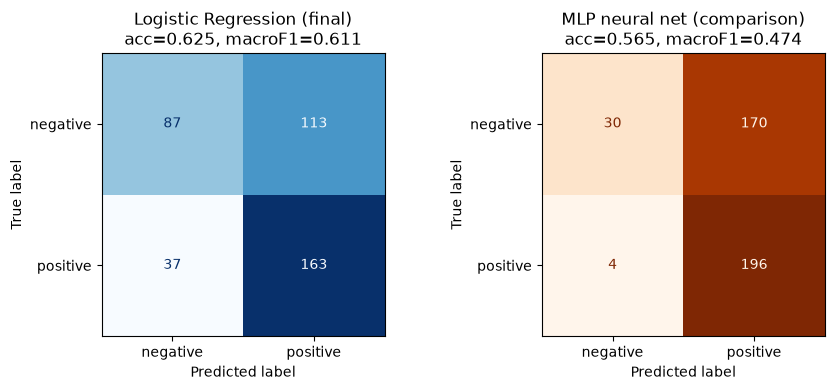

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay(cm_lr, display_labels=['negative', 'positive']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Logistic Regression (final)\nacc={acc_lr:.3f}, macroF1={f1_lr:.3f}')
ConfusionMatrixDisplay(cm_mlp, display_labels=['negative', 'positive']).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f'MLP neural net (comparison)\nacc={acc_mlp:.3f}, macroF1={f1_mlp:.3f}')
plt.tight_layout()
plt.show()

Save Checkpoint and Predictions

In [9]:
os.makedirs('model_checkpoint', exist_ok=True)
joblib.dump(vectorizer, 'model_checkpoint/vectorizer.joblib')
joblib.dump(logreg, 'model_checkpoint/model.joblib')

config = {
    'feature_pipeline': 'TF-IDF(word 1-2gram, min_df=2, max_features=8000, sublinear_tf=True) '
                         'concatenated with 4 VADER sentiment features [neg, neu, pos, compound]',
    'classifier': 'LogisticRegression(C=0.3, class_weight="balanced", max_iter=3000, random_state=42)',
    'label_map': {'0': 'negative', '1': 'positive'},
    'public_test_accuracy': float(acc_lr),
    'public_test_macro_f1': float(f1_lr),
    'comparison_model': {
        'classifier': 'MLPClassifier(...)',
        'public_test_accuracy': float(acc_mlp),
        'public_test_macro_f1': float(f1_mlp),
    },
}
with open('model_checkpoint/config.json', 'w') as f:
    json.dump(config, f, indent=2)

out = pd.DataFrame({'id': test['id'], 'predicted_label': pred_logreg})
out.to_csv('public_test_predictions.csv', index=False)

Verifying it reloads without retraining 

In [10]:
def load_model_and_predict(texts, ckpt_dir='model_checkpoint'):
    vec = joblib.load(f'{ckpt_dir}/vectorizer.joblib')
    clf = joblib.load(f'{ckpt_dir}/model.joblib')
    tfidf = vec.transform(texts)
    rows = [sia.polarity_scores(t) for t in texts]
    vfeat = csr_matrix(np.array([[r['neg'], r['neu'], r['pos'], r['compound']] for r in rows]))
    X = hstack([tfidf, vfeat]).tocsr()
    return clf.predict(X)

fresh_pred = load_model_and_predict(test['text'].values)
print('Fresh checkpoint predictions match saved CSV exactly:', (fresh_pred == pred_logreg).all())

Fresh checkpoint predictions match saved CSV exactly: True
